In [6]:
import torch

torch_version = torch.__version__.split('+')[0]
cuda_version = torch.version.cuda.replace('.', '')

print(f"Fetching wheels for PyTorch {torch_version} and CUDA {cuda_version}...")

!pip install torch-geometric -q
# Removed pyg_lib and torch_spline_conv to bypass the missing wheel error
!pip install torch_scatter torch_sparse torch_cluster -f https://data.pyg.org/whl/torch-{torch_version}+cu{cuda_version}.html -q

print("✅ Installation Done!")

Fetching wheels for PyTorch 2.10.0 and CUDA 128...
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ Installation Done!


In [7]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import (
    EdgeConv,
    TransformerConv,
    global_mean_pool,
    global_max_pool,
    knn_graph
)

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os, warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Imports done | Device: {device}")

✅ Imports done | Device: cuda


In [8]:
if not os.path.exists('test.h5'):
    os.system('wget -q https://zenodo.org/record/2603256/files/test.h5')
    print("✅ Downloaded")

df = pd.read_hdf('test.h5', key='table', start=0, stop=200000)

feature_cols = []
for i in range(200):
    feature_cols.extend([f"E_{i}", f"PX_{i}", f"PY_{i}", f"PZ_{i}"])

X_raw = df[feature_cols].values.reshape(-1, 200, 4).astype(np.float32)
y = df['is_signal_new'].values if 'is_signal_new' in df.columns else df['is_signal'].values

print(f"✅ Loaded: {X_raw.shape} | Signal: {y.mean():.3f}")

✅ Downloaded
✅ Loaded: (200000, 200, 4) | Signal: 0.499


In [9]:
def transform_to_spherical(X_raw):
    E  = X_raw[:, :, 0]
    Px = X_raw[:, :, 1]
    Py = X_raw[:, :, 2]
    Pz = X_raw[:, :, 3]

    Pt  = np.hypot(Px, Py)
    Phi = np.arctan2(Py, Px)
    Eta = np.arcsinh(Pz / (Pt + 1e-6))

    Pt_log = np.log(Pt + 1)
    E_log  = np.log(E  + 1)

    X_final = np.stack([Pt_log, Eta, Phi, E_log], axis=-1)
    X_final = np.nan_to_num(X_final)

    mask = (E < 1e-4)
    X_final[mask] = 0.0

    return X_final, mask

X_final, padding_mask = transform_to_spherical(X_raw)
print(f"✅ Transformed: {X_final.shape}")

✅ Transformed: (200000, 200, 4)


In [10]:
def jet_to_graph(jet_features, pad_mask, k=7):
    real_mask = ~pad_mask
    real_particles = jet_features[real_mask]

    if len(real_particles) <= k:
        if len(real_particles) == 0:
            real_particles = np.zeros((k+1, 4), dtype=np.float32)
        else:
            repeats = k + 1 - len(real_particles)
            real_particles = np.vstack([
                real_particles,
                np.tile(real_particles[0], (repeats, 1))
            ])

    x = torch.tensor(real_particles, dtype=torch.float)
    pos = x[:, 1:3]  # (eta, phi)
    edge_index = knn_graph(pos, k=k, loop=False)
    return Data(x=x, edge_index=edge_index)


print("Building graphs... (~5-10 min for 200k jets)")
graph_list = []
labels = []

for i in range(len(X_final)):
    g = jet_to_graph(X_final[i], padding_mask[i], k=7)
    graph_list.append(g)
    labels.append(int(y[i]))
    if (i+1) % 25000 == 0:
        print(f"  {i+1:,} / {len(X_final):,}")

for i, g in enumerate(graph_list):
    g.y = torch.tensor([labels[i]], dtype=torch.long)

print(f"✅ Done! Sample graph: {graph_list[0].num_nodes} nodes, {graph_list[0].num_edges} edges")

Building graphs... (~5-10 min for 200k jets)
  25,000 / 200,000
  50,000 / 200,000
  75,000 / 200,000
  100,000 / 200,000
  125,000 / 200,000
  150,000 / 200,000
  175,000 / 200,000
  200,000 / 200,000
✅ Done! Sample graph: 17 nodes, 119 edges


In [11]:
train_graphs, val_graphs = train_test_split(
    graph_list, test_size=0.2, random_state=42, stratify=labels
)

BATCH_SIZE = 512
train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_graphs,   batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Train: {len(train_graphs):,} | Val: {len(val_graphs):,}")

✅ Train: 160,000 | Val: 40,000


In [12]:
class LocalGNN(nn.Module):
    def __init__(self, in_channels=4, hidden=64):
        super().__init__()

        self.conv1 = EdgeConv(nn=nn.Sequential(
            nn.Linear(2*in_channels, hidden),
            nn.BatchNorm1d(hidden), nn.ReLU(),
            nn.Linear(hidden, hidden)
        ), aggr='max')

        self.conv2 = EdgeConv(nn=nn.Sequential(
            nn.Linear(2*hidden, hidden*2),
            nn.BatchNorm1d(hidden*2), nn.ReLU(),
            nn.Linear(hidden*2, hidden*2)
        ), aggr='max')

        self.conv3 = EdgeConv(nn=nn.Sequential(
            nn.Linear(2*hidden*2, hidden*4),
            nn.BatchNorm1d(hidden*4), nn.ReLU(),
            nn.Linear(hidden*4, hidden*4)
        ), aggr='max')

        self.classifier = nn.Sequential(
            nn.Linear(hidden*4, 128), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(128, 1)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        x = global_max_pool(x, batch)
        return torch.sigmoid(self.classifier(x)).squeeze(-1)


model_local = LocalGNN().to(device)
print(f"✅ Local GNN | Params: {sum(p.numel() for p in model_local.parameters()):,}")

✅ Local GNN | Params: 203,265


In [13]:
def build_full_graph(batch):
    """Every node attends to every other node in same jet — non-local."""
    edges = []
    for b in range(batch.max().item() + 1):
        idx = (batch == b).nonzero(as_tuple=True)[0]
        n = len(idx)
        if n > 1:
            src = idx.repeat_interleave(n)
            dst = idx.repeat(n)
            mask = src != dst
            edges.append(torch.stack([src[mask], dst[mask]]))
    return torch.cat(edges, dim=1)


class NonLocalGNN(nn.Module):
    def __init__(self, in_channels=4, hidden=64, heads=4):
        super().__init__()

        self.proj = nn.Linear(in_channels, hidden)

        self.conv1 = TransformerConv(hidden, hidden//heads, heads=heads, dropout=0.1)
        self.norm1 = nn.LayerNorm(hidden)
        self.ffn1  = nn.Sequential(nn.Linear(hidden, hidden*2), nn.GELU(), nn.Linear(hidden*2, hidden))

        self.conv2 = TransformerConv(hidden, hidden//heads, heads=heads, dropout=0.1)
        self.norm2 = nn.LayerNorm(hidden)
        self.ffn2  = nn.Sequential(nn.Linear(hidden, hidden*2), nn.GELU(), nn.Linear(hidden*2, hidden))

        self.conv3 = TransformerConv(hidden, hidden//heads, heads=heads, dropout=0.1)
        self.norm3 = nn.LayerNorm(hidden)
        self.ffn3  = nn.Sequential(nn.Linear(hidden, hidden*2), nn.GELU(), nn.Linear(hidden*2, hidden))

        self.classifier = nn.Sequential(
            nn.Linear(hidden*2, 128), nn.GELU(),
            nn.Dropout(0.3), nn.Linear(128, 1)
        )

    def forward(self, data):
        x, batch = data.x, data.batch
        edge_index = build_full_graph(batch)  # Non-local: fully connected

        x = F.gelu(self.proj(x))

        r = x; x = self.norm1(self.conv1(x, edge_index) + r); x = x + self.ffn1(x)
        r = x; x = self.norm2(self.conv2(x, edge_index) + r); x = x + self.ffn2(x)
        r = x; x = self.norm3(self.conv3(x, edge_index) + r); x = x + self.ffn3(x)

        x = torch.cat([global_mean_pool(x, batch),
                        global_max_pool(x, batch)], dim=-1)
        return torch.sigmoid(self.classifier(x)).squeeze(-1)


model_nonlocal = NonLocalGNN().to(device)
print(f"✅ Non-local GNN | Params: {sum(p.numel() for p in model_nonlocal.parameters()):,}")

✅ Non-local GNN | Params: 116,993


In [14]:
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    criterion = nn.BCELoss()
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        pred = model(batch)
        loss = criterion(pred, batch.y.float())
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds, labs = [], []
    for batch in loader:
        batch = batch.to(device)
        preds.extend(model(batch).cpu().numpy())
        labs.extend(batch.y.cpu().numpy())
    auc = roc_auc_score(labs, preds)
    return auc, np.array(preds), np.array(labs)

def train_model(model, name, epochs=20, lr=1e-3):
    opt = Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sch = CosineAnnealingLR(opt, T_max=epochs)
    best_auc, best_preds, best_labs = 0, None, None
    history = []

    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    print(f"{'Epoch':>5} | {'Loss':>8} | {'AUC':>8} | {'Best':>6}")
    print("-"*35)

    for ep in range(1, epochs+1):
        loss = train_epoch(model, train_loader, opt)
        auc, preds, labs = evaluate(model, val_loader)
        sch.step()
        history.append((loss, auc))
        if auc > best_auc:
            best_auc, best_preds, best_labs = auc, preds, labs
        print(f"{ep:>5} | {loss:>8.5f} | {auc:>8.5f} | {best_auc:>6.4f}"
              + (" ⭐" if auc == best_auc else ""))

    print(f"\n  BEST AUC: {best_auc:.5f}")
    return best_auc, best_preds, best_labs, history

print("✅ Training functions ready")

✅ Training functions ready


In [15]:
model_local = LocalGNN().to(device)
auc_local, preds_local, labs_local, hist_local = train_model(
    model_local, "Local GNN (EdgeConv — k=7 neighbors)", epochs=20, lr=1e-3
)


  Local GNN (EdgeConv — k=7 neighbors)
Epoch |     Loss |      AUC |   Best
-----------------------------------
    1 |  0.38564 |  0.93648 | 0.9365 ⭐
    2 |  0.29863 |  0.95082 | 0.9508 ⭐
    3 |  0.27218 |  0.95649 | 0.9565 ⭐
    4 |  0.26110 |  0.95793 | 0.9579 ⭐
    5 |  0.25258 |  0.95869 | 0.9587 ⭐
    6 |  0.24643 |  0.96146 | 0.9615 ⭐
    7 |  0.23784 |  0.95974 | 0.9615
    8 |  0.23270 |  0.96160 | 0.9616 ⭐
    9 |  0.22521 |  0.96206 | 0.9621 ⭐
   10 |  0.21894 |  0.96276 | 0.9628 ⭐
   11 |  0.21137 |  0.96224 | 0.9628
   12 |  0.20396 |  0.96290 | 0.9629 ⭐
   13 |  0.19533 |  0.96251 | 0.9629
   14 |  0.18440 |  0.96247 | 0.9629
   15 |  0.17399 |  0.96212 | 0.9629
   16 |  0.16411 |  0.96206 | 0.9629
   17 |  0.15588 |  0.96190 | 0.9629
   18 |  0.14801 |  0.96151 | 0.9629
   19 |  0.14345 |  0.96152 | 0.9629
   20 |  0.14018 |  0.96149 | 0.9629

  BEST AUC: 0.96290


In [16]:
model_nonlocal = NonLocalGNN().to(device)
auc_nonlocal, preds_nonlocal, labs_nonlocal, hist_nonlocal = train_model(
    model_nonlocal, "Non-local GNN (Graph Transformer — Fully Connected)", epochs=20, lr=5e-4
)


  Non-local GNN (Graph Transformer — Fully Connected)
Epoch |     Loss |      AUC |   Best
-----------------------------------
    1 |  0.49134 |  0.90897 | 0.9090 ⭐
    2 |  0.31468 |  0.94448 | 0.9445 ⭐
    3 |  0.27628 |  0.95352 | 0.9535 ⭐
    4 |  0.26194 |  0.95916 | 0.9592 ⭐
    5 |  0.25009 |  0.96293 | 0.9629 ⭐
    6 |  0.24109 |  0.96631 | 0.9663 ⭐
    7 |  0.23190 |  0.96696 | 0.9670 ⭐
    8 |  0.22463 |  0.96936 | 0.9694 ⭐
    9 |  0.22012 |  0.96915 | 0.9694
   10 |  0.21483 |  0.97021 | 0.9702 ⭐
   11 |  0.21152 |  0.97211 | 0.9721 ⭐
   12 |  0.20873 |  0.97224 | 0.9722 ⭐
   13 |  0.20577 |  0.97342 | 0.9734 ⭐
   14 |  0.20309 |  0.97418 | 0.9742 ⭐
   15 |  0.20153 |  0.97448 | 0.9745 ⭐
   16 |  0.19954 |  0.97420 | 0.9745
   17 |  0.19812 |  0.97475 | 0.9747 ⭐
   18 |  0.19736 |  0.97490 | 0.9749 ⭐
   19 |  0.19595 |  0.97495 | 0.9750 ⭐
   20 |  0.19535 |  0.97494 | 0.9750

  BEST AUC: 0.97495



         FINAL BENCHMARK RESULTS
  Local GNN (EdgeConv)                     0.96290
  Particle Transformer (Sequence)          0.92652
  Non-local GNN (Graph Transformer)        0.97495 ← KEY RESULT
  Bi-GRU                                   0.94097
  Ensemble (GRU + Transformer)             0.94185

  Improvement (Non-local vs Local): +0.0121 AUC


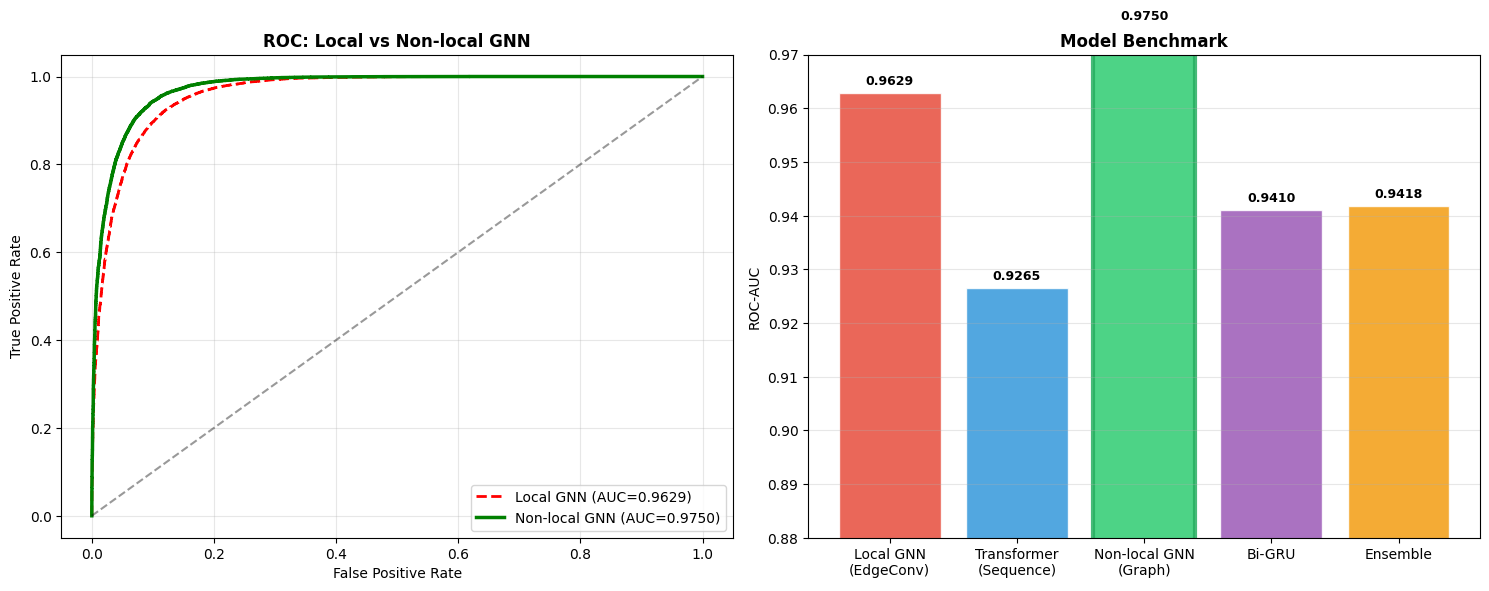

In [17]:
# My previous results
auc_transformer = 0.92652
auc_gru         = 0.94097
auc_ensemble    = 0.94185

# Print comparison table
print("\n" + "="*55)
print("         FINAL BENCHMARK RESULTS")
print("="*55)
models = {
    "Local GNN (EdgeConv)":             auc_local,
    "Particle Transformer (Sequence)":  auc_transformer,
    "Non-local GNN (Graph Transformer)":auc_nonlocal,
    "Bi-GRU":                           auc_gru,
    "Ensemble (GRU + Transformer)":     auc_ensemble,
}
for name, auc in models.items():
    tag = " ← KEY RESULT" if "Non-local" in name else ""
    print(f"  {name:<40} {auc:.5f}{tag}")
print("="*55)
print(f"\n  Improvement (Non-local vs Local): +{auc_nonlocal - auc_local:.4f} AUC")

# ROC plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ROC curves
fpr_l, tpr_l, _ = roc_curve(labs_local,    preds_local)
fpr_n, tpr_n, _ = roc_curve(labs_nonlocal, preds_nonlocal)

axes[0].plot(fpr_l, tpr_l, 'r--', lw=2, label=f'Local GNN (AUC={auc_local:.4f})')
axes[0].plot(fpr_n, tpr_n, 'g-',  lw=2.5, label=f'Non-local GNN (AUC={auc_nonlocal:.4f})')
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC: Local vs Non-local GNN', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Bar chart
names  = ['Local GNN\n(EdgeConv)', 'Transformer\n(Sequence)',
          'Non-local GNN\n(Graph)', 'Bi-GRU', 'Ensemble']
aucs   = [auc_local, auc_transformer, auc_nonlocal, auc_gru, auc_ensemble]
colors = ['#e74c3c','#3498db','#2ecc71','#9b59b6','#f39c12']
bars   = axes[1].bar(names, aucs, color=colors, alpha=0.85, edgecolor='white')
for bar, auc in zip(bars, aucs):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                 f'{auc:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_ylim([0.88, 0.97]); axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('Model Benchmark', fontweight='bold'); axes[1].grid(axis='y', alpha=0.3)
bars[2].set_edgecolor('#27ae60'); bars[2].set_linewidth(3)

plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
import torch
from google.colab import files

# 1. Save the trained weights to the Colab instance
torch.save(model_local.state_dict(), 'local_gnn_weights.pth')
torch.save(model_nonlocal.state_dict(), 'nonlocal_gnn_weights.pth')
print("✅ Weights saved to Colab! Downloading to desktop now...")

# 2. Trigger browser download to your physical computer
files.download('local_gnn_weights.pth')
files.download('nonlocal_gnn_weights.pth')

✅ Weights saved to Colab! Downloading to desktop now...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>